# REPORT
## Introduction to the Design and Analysis of Algorithms
### Solutions to Chapter 1 Exercises

**Exercises 1.1** (Nos. 4, 6-9) and **1.2** (Nos. 4, 5, 6, 9) + two warm-up tasks (maximum and average of an array)

Textbook: A. Levitin, *Introduction to the Design and Analysis of Algorithms*

Prepared by: Sati

---
Pseudocode is typeset with LaTeX (MathJax) inside the notebook in the style of the `algorithm2e` package; the Appendix contains ready-to-compile `algorithm2e` / `algpseudocode` sources. Every algorithm is followed by a Python implementation and a check.

In [1]:
import math, random, time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", None)

---
# 0. Warm-up tasks
## 0.1 Maximum value in an array
**Idea.** Keep the largest element seen so far. *Loop invariant:* after processing $A[0..i]$, the variable $m$ equals $\max A[0..i]$.

**Algorithm 1: MaxValue(A[0..n-1])**

*Input:* array $A[0..n-1]$ of numbers, $n\ge 1$  
*Output:* the largest element of $A$

$$
\begin{array}{rl}
\hline
1 & m \leftarrow A[0] \\
2 & \textbf{for}\ i \leftarrow 1\ \textbf{to}\ n-1\ \textbf{do} \\
3 & \quad\ \textbf{if}\ A[i] > m\ \textbf{then}\ m \leftarrow A[i]\quad\triangleright\ \text{invariant: m = max A[0..i]} \\
4 & \textbf{return}\ m \\
\hline
\end{array}
$$

**Complexity.** exactly $n-1$ comparisons, so $\Theta(n)$; no algorithm can do better, because every element must be looked at.

In [2]:
def max_value(A):
    if not A:
        raise ValueError("empty array")
    m, comparisons = A[0], 0
    for i in range(1, len(A)):
        comparisons += 1
        if A[i] > m:
            m = A[i]
    return m, comparisons

A = [7, -3, 12, 5, 12, 0, -8]
print("max =", max_value(A))
for _ in range(1000):
    B = [random.randint(-100, 100) for _ in range(random.randint(1, 50))]
    assert max_value(B)[0] == max(B) and max_value(B)[1] == len(B) - 1
print("random tests passed")

max = (12, 6)
random tests passed


## 0.2 Average of the numbers in an array
$$\bar A=\frac{1}{n}\sum_{i=0}^{n-1}A[i]$$

**Algorithm 2: Average(A[0..n-1])**

*Input:* array $A[0..n-1]$ of numbers, $n\ge 1$  
*Output:* the arithmetic mean of $A$

$$
\begin{array}{rl}
\hline
1 & s \leftarrow 0 \\
2 & \textbf{for}\ i \leftarrow 0\ \textbf{to}\ n-1\ \textbf{do} \\
3 & \quad\ s \leftarrow s + A[i] \\
4 & \textbf{return}\ s / n \\
\hline
\end{array}
$$

**Complexity.** $n$ additions and one division, so $\Theta(n)$.

In [3]:
def average(A):
    if not A:
        raise ValueError("empty array")
    s = 0
    for x in A:
        s += x
    return s / len(A)

print("average =", average([7, -3, 12, 5, 12, 0, -8]))
for _ in range(1000):
    B = [random.randint(-100, 100) for _ in range(random.randint(1, 50))]
    assert math.isclose(average(B), sum(B) / len(B))
print("random tests passed")

average = 3.5714285714285716
random tests passed


---
# 1. Exercises 1.1
## 1.1 Exercise 1.1.4 - Computing $\lfloor\sqrt n\rfloor$

> **Problem 1.1.4.** Design an algorithm for computing $\sqrt n$ for any positive integer $n$. Besides assignment and comparison, your algorithm may only use the four basic arithmetical operations.

### Idea
The integer part $r=\lfloor\sqrt n\rfloor$ is the largest integer with $r^2\le n$. Start with $r=0$ and increase $r$ while $(r+1)^2\le n$. *Loop invariant:* $r^2\le n$. When the loop stops, $(r+1)^2>n$, hence $r^2\le n<(r+1)^2$, i.e. $r=\lfloor\sqrt n\rfloor$.

**Algorithm 3: FloorSqrt(n) - linear search**

*Input:* an integer $n\ge1$  
*Output:* $\lfloor\sqrt n\rfloor$

$$
\begin{array}{rl}
\hline
1 & r \leftarrow 0 \\
2 & \textbf{while}\ (r+1)\cdot(r+1)\le n\ \textbf{do} \\
3 & \quad\ r \leftarrow r+1\quad\triangleright\ \text{invariant: r^2 \le n} \\
4 & \textbf{return}\ r \\
\hline
\end{array}
$$

**Complexity.** $\lfloor\sqrt n\rfloor$ iterations, i.e. $O(\sqrt n)$.

### Speed-up: binary search
If "/" is understood as integer division, search on $[0,n+1)$ with invariant $l^2\le n<r^2$.

**Algorithm 4: FloorSqrtBinary(n) - binary search**

*Input:* an integer $n\ge1$  
*Output:* $\lfloor\sqrt n\rfloor$

$$
\begin{array}{rl}
\hline
1 & l \leftarrow 0;\ r \leftarrow n+1 \\
2 & \textbf{while}\ r-l>1\ \textbf{do} \\
3 & \quad\ m \leftarrow (l+r)\ \operatorname{div}\ 2 \\
4 & \quad\ \textbf{if}\ m\cdot m\le n\ \textbf{then}\ l\leftarrow m\ \textbf{else}\ r\leftarrow m \\
5 & \textbf{return}\ l \\
\hline
\end{array}
$$

Each iteration halves $r-l$, so the running time is $O(\log n)$.

### Real-valued $\sqrt n$ (bisection, only $+,-,\cdot,/$ and comparisons)
Search on $[0,\max(1,n)]$: if $m^2\le n$ then $l\leftarrow m$, else $r\leftarrow m$, until $r-l\le\varepsilon$. The number of iterations is $\lceil\log_2(\max(1,n)/\varepsilon)\rceil$.

In [4]:
def floor_sqrt_linear(n):
    r, it = 0, 0
    while (r + 1) * (r + 1) <= n:
        r += 1; it += 1
    return r, it

def floor_sqrt_binary(n):
    l, r, it = 0, n + 1, 0
    while r - l > 1:
        m = (l + r) // 2
        if m * m <= n: l = m
        else:          r = m
        it += 1
    return l, it

def sqrt_bisect(n, eps=1e-12):
    l, r, it = 0.0, float(max(1, n)), 0
    while r - l > eps:
        m = (l + r) / 2
        if m * m <= n: l = m
        else:          r = m
        it += 1
    return l, it

for n in range(1, 20001):
    assert floor_sqrt_linear(n)[0] == floor_sqrt_binary(n)[0] == math.isqrt(n)
print("n = 17 ->", floor_sqrt_linear(17))
rows = [(n, floor_sqrt_linear(n)[1], floor_sqrt_binary(n)[1]) for n in (10**2, 10**4, 10**6, 10**8)]
display(pd.DataFrame(rows, columns=["n", "iterations (linear)", "iterations (binary)"]))
print("sqrt(2) ~", sqrt_bisect(2)[0], "| math.sqrt(2) =", math.sqrt(2), "| iterations:", sqrt_bisect(2)[1])

n = 17 -> (4, 4)


,n,iterations (linear),iterations (binary)
0,100,10,7
1,10000,100,14
2,1000000,1000,20
3,100000000,10000,27


sqrt(2) ~ 1.4142135623724243 | math.sqrt(2) = 1.4142135623730951 | iterations: 41


---
## 1.2 Exercise 1.1.6 - $\gcd(31415,\,14142)$

> **Problem 1.1.6.** a. Find $\gcd(31415,14142)$ by applying Euclid's algorithm. b. Estimate how many times faster it will be to find $\gcd(31415,14142)$ by Euclid's algorithm compared with the algorithm based on checking consecutive integers from $\min\{m,n\}$ down to $\gcd(m,n)$.

### a. Euclid's algorithm

**Algorithm 5: Euclid(m, n)**

*Input:* non-negative integers $m,n$, not both zero  
*Output:* $\gcd(m,n)$

$$
\begin{array}{rl}
\hline
1 & \textbf{while}\ n\ne0\ \textbf{do} \\
2 & \quad\ r \leftarrow m \bmod n \\
3 & \quad\ m \leftarrow n \\
4 & \quad\ n \leftarrow r \\
5 & \textbf{return}\ m \\
\hline
\end{array}
$$

In [5]:
def euclid_trace(m, n):
    rows = []
    while n != 0:
        r = m % n
        rows.append((len(rows) + 1, m, n, r))
        m, n = n, r
    return m, rows

g, rows = euclid_trace(31415, 14142)
display(pd.DataFrame(rows, columns=["step", "m", "n", "r = m mod n"]).set_index("step"))
print("gcd(31415, 14142) =", g, "| number of divisions =", len(rows))
assert g == math.gcd(31415, 14142) == 1 and len(rows) == 10

,m,n,r = m mod n
step,,,
1,31415,14142,3131
2,14142,3131,1618
3,3131,1618,1513
4,1618,1513,105
5,1513,105,43
6,105,43,19
7,43,19,5
8,19,5,4
9,5,4,1


gcd(31415, 14142) = 1 | number of divisions = 10


### b. Comparison with consecutive integer checking

**Algorithm 6: ConsecutiveIntegerCheck(m, n)**

*Input:* positive integers $m,n$  
*Output:* $\gcd(m,n)$

$$
\begin{array}{rl}
\hline
1 & t \leftarrow \min\{m,n\} \\
2 & \textbf{while}\ \mathrm{true}\ \textbf{do} \\
3 & \quad\ \textbf{if}\ m \bmod t = 0\ \textbf{then} \\
4 & \quad\ \quad\ \textbf{if}\ n \bmod t = 0\ \textbf{then}\ \textbf{return}\ t \\
5 & \quad\ t \leftarrow t-1 \\
\hline
\end{array}
$$

Since $\gcd=1$, $t$ runs through all values $14142,14141,\dots,1$: $14142$ iterations, each with the division $m\bmod t$. The second division $n \bmod t$ happens only when $t\mid 31415=5\cdot61\cdot103$. Such $t\le14142$ are $6283,\,515,\,305,\,103,\,61,\,5,\,1$ - seven values. Hence
$$14142+7=14149\ \text{divisions},\qquad \frac{14149}{10}\approx 1415 .$$

In [6]:
def consecutive_check(m, n):
    t, divisions = min(m, n), 0
    while True:
        divisions += 1
        if m % t == 0:
            divisions += 1
            if n % t == 0:
                return t, divisions
        t -= 1

g2, d2 = consecutive_check(31415, 14142)
print("gcd =", g2, "| divisions (consecutive check) =", d2, "| divisions (Euclid) =", len(rows))
print("speed-up in divisions: %.1f" % (d2 / len(rows)))
print("divisors of 31415 up to 14142:", sorted([t for t in range(1, 14143) if 31415 % t == 0], reverse=True))
assert d2 == 14149

gcd = 1 | divisions (consecutive check) = 14149 | divisions (Euclid) = 10
speed-up in divisions: 1414.9
divisors of 31415 up to 14142: [6283, 515, 305, 103, 61, 5, 1]


**Answer:** $\gcd(31415,14142)=1$; Euclid's algorithm makes 10 divisions, consecutive integer checking makes 14149, so Euclid's algorithm is about $1.4\cdot10^{3}$ times faster.

---
## 1.3 Exercise 1.1.7 - $\gcd(m,n)=\gcd(n,\,m \bmod n)$

> **Problem 1.1.7.** Prove the equality $\gcd(m,n)=\gcd(n,m\bmod n)$ for every pair of positive integers $m$ and $n$.

**Claim.** Let $m,n>0$ and $r=m\bmod n$. Then $\gcd(m,n)=\gcd(n,r)$.

**Proof.** By definition of the remainder, $m=qn+r$, where $q=\lfloor m/n\rfloor$ and $0\le r<n$. We show that the pairs $(m,n)$ and $(n,r)$ have the same set of common divisors.

* Let $d\mid m$ and $d\mid n$. Then $d\mid m-qn=r$, so $d$ is a common divisor of $n$ and $r$.
* Let $d\mid n$ and $d\mid r$. Then $d\mid qn+r=m$, so $d$ is a common divisor of $m$ and $n$.

The sets of common divisors coincide, hence so do their largest elements: $\gcd(m,n)=\gcd(n,r)$. $\blacksquare$

**Corollary (correctness of Euclid's algorithm).** Each iteration preserves $\gcd(m,n)$. Since $n$ strictly decreases ($0\le r<n$), the loop terminates with $n=0$, and $\gcd(m,0)=m$.

In [7]:
for m in range(1, 301):
    for n in range(1, 301):
        assert math.gcd(m, n) == math.gcd(n, m % n)
print("numerical check passed for all 1 <= m, n <= 300")

numerical check passed for all 1 <= m, n <= 300

---
## 1.4 Exercise 1.1.8 - Euclid's algorithm when $m<n$

> **Problem 1.1.8.** What does Euclid's algorithm do for a pair of integers in which the first is smaller than the second? What is the maximum number of times this can happen during the algorithm's execution on such an input?

If $m<n$, then $m\bmod n=m$. Therefore the first iteration performs $r\leftarrow m,\ m\leftarrow n,\ n\leftarrow m_{\text{old}}$, i.e. it simply **swaps** the numbers: $(m,n)\to(n,m)$. After that the algorithm proceeds as usual.

**Algorithm 7: EuclidCount(m, n) - counting divisions and swaps**

*Input:* positive integers $m,n$  
*Output:* $\gcd(m,n)$, number of divisions $d$, number of swaps $s$

$$
\begin{array}{rl}
\hline
1 & d \leftarrow 0;\ s \leftarrow 0 \\
2 & \textbf{while}\ n\ne0\ \textbf{do} \\
3 & \quad\ \textbf{if}\ m<n\ \textbf{then}\ s\leftarrow s+1\quad\triangleright\ \text{here m mod n = m: a swap} \\
4 & \quad\ r \leftarrow m \bmod n;\ d \leftarrow d+1 \\
5 & \quad\ m \leftarrow n;\ n \leftarrow r \\
6 & \textbf{return}\ m,\ d,\ s \\
\hline
\end{array}
$$

**Why a swap can happen at most once.** After the first iteration the pair is $(n,r)$ with $r<n$. At every later step the pair has the form $(a,b)$, where $b$ is a remainder of a division by $a$, so $b<a$. Thus $m<n$ can hold only in the very first iteration.

In [8]:
def euclid_count(m, n):
    d = s = 0
    while n != 0:
        if m < n: s += 1
        r = m % n; d += 1
        m, n = n, r
    return m, d, s

print("EuclidCount(12, 30) =", euclid_count(12, 30), "(gcd, divisions, swaps)")
for m in range(1, 201):
    for n in range(1, 201):
        g, d, s = euclid_count(m, n)
        assert s == (1 if m < n else 0)
print("for all 1 <= m, n <= 200: swaps = 1 if m < n, otherwise 0")

EuclidCount(12, 30) = (6, 3, 1) (gcd, divisions, swaps)


for all 1 <= m, n <= 200: swaps = 1 if m < n, otherwise 0


**Answer:** for $m<n$ the algorithm swaps the numbers in the first iteration and then works as for $m\ge n$. This can happen **at most once** (only in the first iteration).

---
## 1.5 Exercise 1.1.9 - Number of divisions for $1\le m,n\le10$

> **Problem 1.1.9.** a. What is the minimum number of divisions made by Euclid's algorithm among all inputs $1\le m,n\le10$? b. What is the maximum?

**Algorithm 8: MinMaxDivisions(N)**

*Input:* an integer $N$ (here $N=10$)  
*Output:* minimum and maximum number of divisions over all pairs $1\le m,n\le N$

$$
\begin{array}{rl}
\hline
1 & d_{\min}\leftarrow\infty;\ d_{\max}\leftarrow 0 \\
2 & \textbf{for}\ m\leftarrow1\ \textbf{to}\ N\ \textbf{do} \\
3 & \quad\ \textbf{for}\ n\leftarrow1\ \textbf{to}\ N\ \textbf{do} \\
4 & \quad\ \quad\ (\_,d,\_)\leftarrow \textrm{EuclidCount}(m,n) \\
5 & \quad\ \quad\ \textbf{if}\ d<d_{\min}\ \textbf{then}\ d_{\min}\leftarrow d \\
6 & \quad\ \quad\ \textbf{if}\ d>d_{\max}\ \textbf{then}\ d_{\max}\leftarrow d \\
7 & \textbf{return}\ d_{\min},\ d_{\max} \\
\hline
\end{array}
$$

**a. Minimum.** The first division is always performed, so $d\ge1$; exactly one division occurs when $n\mid m$ (then $r=0$ at once), e.g. $(10,5)$ or $(1,1)$.

**b. Maximum.** The worst cases are consecutive Fibonacci numbers (Lame's theorem). Up to 10 this is $(8,5)$: $8\bmod5=3,\ 5\bmod3=2,\ 3\bmod2=1,\ 2\bmod1=0\Rightarrow 4$ divisions. For the reversed order $(5,8)$ one more division (the swap) is added, so the total is $1+4=5$.

In [9]:
def min_max_divisions(N):
    table = {(m, n): euclid_count(m, n)[1] for m in range(1, N + 1) for n in range(1, N + 1)}
    return min(table.values()), max(table.values()), table

dmin, dmax, table = min_max_divisions(10)
print("minimum =", dmin, "| maximum =", dmax)
print("pairs with max:", [p for p, d in table.items() if d == dmax])
print("pairs with min (first 10):", [p for p, d in table.items() if d == dmin][:10], "...")
dist = pd.Series(table).value_counts().sort_index().rename("number of pairs")
display(dist.rename_axis("divisions").to_frame())
assert (dmin, dmax) == (1, 5)

minimum = 1 | maximum = 5
pairs with max: [(5, 8)]
pairs with min (first 10): [(1, 1), (2, 1), (2, 2), (3, 1), (3, 3), (4, 1), (4, 2), (4, 4), (5, 1), (5, 5)] ...


,number of pairs
divisions,
1,27
2,36
3,27
4,9
5,1


**Answer:** a. minimum $=1$ division; b. maximum $=5$ divisions (pair $(5,8)$).

---
# 2. Exercises 1.2
## 2.1 Exercise 1.2.4 - Real roots of $ax^2+bx+c=0$

> **Problem 1.2.4.** Write pseudocode for an algorithm for finding real roots of the equation $ax^2+bx+c=0$ for arbitrary real coefficients $a,b,c$. (You may assume the availability of $\mathrm{sqrt}(x)$.)

All cases must be considered:

* $a=0$: the equation is linear, $bx+c=0$; if $b=0$ there is either no solution ($c\ne0$) or infinitely many ($c=0$);
* $a\ne0$: the discriminant is $D=b^2-4ac$; for $D<0$ there are no real roots, for $D=0$ one root, for $D>0$ two roots.

**Algorithm 9: QuadraticRoots(a, b, c)**

*Input:* real numbers $a,b,c$  
*Output:* the set of real roots of $ax^2+bx+c=0$

$$
\begin{array}{rl}
\hline
1 & \textbf{if}\ a=0\ \textbf{then} \\
2 & \quad\ \textbf{if}\ b=0\ \textbf{then} \\
3 & \quad\ \quad\ \textbf{if}\ c=0\ \textbf{then}\ \textrm{print ``every real } x \textrm{ is a solution''} \\
4 & \quad\ \quad\ \textbf{else}\ \textrm{print ``no roots''} \\
5 & \quad\ \textbf{else}\ \textrm{print } x=-c/b\quad\triangleright\ \text{linear equation} \\
6 & \textbf{else} \\
7 & \quad\ D \leftarrow b\cdot b-4\cdot a\cdot c \\
8 & \quad\ \textbf{if}\ D<0\ \textbf{then}\ \textrm{print ``no real roots''} \\
9 & \quad\ \textbf{else if}\ D=0\ \textbf{then}\ \textrm{print } x=-b/(2a)\quad\triangleright\ \text{double root} \\
10 & \quad\ \textbf{else} \\
11 & \quad\ \quad\ s\leftarrow \mathrm{sqrt}(D) \\
12 & \quad\ \quad\ x_1\leftarrow(-b+s)/(2a);\ x_2\leftarrow(-b-s)/(2a) \\
13 & \quad\ \quad\ \textrm{print } x_1,\ x_2 \\
\hline
\end{array}
$$

**Remark (floating point).** If $b^2\gg|4ac|$, subtracting nearly equal numbers loses precision. Then use $q=-\tfrac12\bigl(b+\operatorname{sgn}(b)\sqrt D\bigr)$, $x_1=q/a$, $x_2=c/q$.

In [10]:
def quadratic_roots(a, b, c):
    if a == 0:
        if b == 0:
            return "every real x" if c == 0 else []
        return [-c / b]
    D = b * b - 4 * a * c
    if D < 0:
        return []
    if D == 0:
        return [-b / (2 * a)]
    s = math.sqrt(D)
    return [(-b + s) / (2 * a), (-b - s) / (2 * a)]

def quadratic_roots_stable(a, b, c):
    if a == 0 or b * b - 4 * a * c <= 0:
        return quadratic_roots(a, b, c)
    s = math.sqrt(b * b - 4 * a * c)
    q = -0.5 * (b + math.copysign(s, b))
    return [q / a, c / q]

tests = [(1, -3, 2), (1, 2, 5), (0, 2, -6), (1, -2, 1), (0, 0, 0), (0, 0, 5), (2, 0, -8)]
for t in tests:
    print("a, b, c =", t, "->", quadratic_roots(*t))
print()
a, b, c = 1, 1e8, 1
print("naive :", sorted(quadratic_roots(a, b, c)))
print("stable:", sorted(quadratic_roots_stable(a, b, c)), "(exact small root is about -1e-8)")

a, b, c = (1, -3, 2) -> [2.0, 1.0]
a, b, c = (1, 2, 5) -> []
a, b, c = (0, 2, -6) -> [3.0]
a, b, c = (1, -2, 1) -> [1.0]
a, b, c = (0, 0, 0) -> every real x
a, b, c = (0, 0, 5) -> []
a, b, c = (2, 0, -8) -> [2.0, -2.0]

naive : [-100000000.0, -7.450580596923828e-09]
stable: [-100000000.0, -1e-08] (exact small root is about -1e-8)


---
## 2.2 Exercise 1.2.5 - Binary representation

> **Problem 1.2.5.** Describe the standard algorithm for finding the binary representation of a positive decimal integer a. in English; b. in pseudocode.

### a. Description in English
1. Divide $n$ by 2 (integer division) and record the remainder (0 or 1).
2. Replace $n$ by the quotient. If $n>0$, return to step 1.
3. Write the remainders in the reverse order of their computation: the last remainder is the most significant bit.

### b. Pseudocode

**Algorithm 10: ToBinary(n)**

*Input:* a positive integer $n$ (decimal)  
*Output:* array $B[0..k-1]$, where $B[k-1]$ is the most significant bit

$$
\begin{array}{rl}
\hline
1 & k\leftarrow0 \\
2 & \textbf{while}\ n>0\ \textbf{do} \\
3 & \quad\ B[k]\leftarrow n\bmod 2\quad\triangleright\ \text{next bit, from the least significant} \\
4 & \quad\ n\leftarrow n\ \operatorname{div}\ 2 \\
5 & \quad\ k\leftarrow k+1 \\
6 & \textbf{for}\ i\leftarrow k-1\ \textbf{downto}\ 0\ \textbf{do}\ \textrm{print } B[i] \\
\hline
\end{array}
$$

The number of iterations is $\lfloor\log_2 n\rfloor+1$.

In [11]:
def to_binary(n):
    B, steps = [], []
    while n > 0:
        steps.append((n, n % 2))
        B.append(n % 2)
        n //= 2
    return "".join(str(b) for b in reversed(B)), steps

s, steps = to_binary(25)
display(pd.DataFrame(steps, columns=["n", "n mod 2"]).T)
print("25 in binary:", s, "| check: 16 + 8 + 1 =", 16 + 8 + 1)
for n in range(1, 5001):
    assert to_binary(n)[0] == bin(n)[2:]
    assert len(to_binary(n)[1]) == int(math.log2(n)) + 1
print("verified against bin() for n = 1..5000; iterations = floor(log2 n) + 1")

,0,1,2,3,4
n,25,12,6,3,1
n mod 2,1,0,0,1,1


25 in binary: 11001 | check: 16 + 8 + 1 = 25
verified against bin() for n = 1..5000; iterations = floor(log2 n) + 1


---
## 2.3 Exercise 1.2.6 - ATM cash-dispensing algorithm

> **Problem 1.2.6.** Describe the algorithm used by your favorite ATM machine in dispensing cash.

**Assumptions.** The ATM holds $k$ denominations $D[1]>D[2]>\dots>D[k]$ and the cassette contains $C[i]$ bills of value $D[i]$. The denominations form a "canonical" system (e.g. 100, 50, 20, 10), so the greedy choice minimizes the number of bills. Inputs: card, PIN, amount $S$. The account has a known balance, a daily limit, and the amount already withdrawn today.

**Algorithm 11: ATMDispense**

*Input:* bank card, PIN, requested amount $S$  
*Output:* dispensed bills $take[1..k]$ or a refusal message

$$
\begin{array}{rl}
\hline
1 & \textbf{if}\ \textrm{card is unreadable or invalid}\ \textbf{then}\ \textrm{eject card; stop} \\
2 & attempts\leftarrow0;\ ok\leftarrow\mathrm{false} \\
3 & \textbf{while}\ attempts<3\ \textrm{and not}\ ok\ \textbf{do} \\
4 & \quad\ \textrm{read PIN} \\
5 & \quad\ \textbf{if}\ \textrm{PIN is correct}\ \textbf{then}\ ok\leftarrow\mathrm{true}\ \textbf{else}\ attempts\leftarrow attempts+1 \\
6 & \textbf{if}\ \textrm{not}\ ok\ \textbf{then}\ \textrm{retain card; stop} \\
7 & \textrm{read amount } S \\
8 & \textbf{if}\ S\le0\ \textrm{or}\ S\bmod D[k]\ne0\ \textbf{then}\ \textrm{refuse: amount must be a multiple of } D[k] \\
9 & \textbf{else if}\ S>balance\ \textbf{then}\ \textrm{refuse: insufficient funds} \\
10 & \textbf{else if}\ withdrawn+S>limit\ \textbf{then}\ \textrm{refuse: daily limit exceeded} \\
11 & \textbf{else if}\ S>\sum_{i=1}^{k}D[i]\cdot C[i]\ \textbf{then}\ \textrm{refuse: ATM has insufficient cash} \\
12 & rest\leftarrow S\quad\triangleright\ \text{greedy selection of bills} \\
13 & \textbf{for}\ i\leftarrow1\ \textbf{to}\ k\ \textbf{do} \\
14 & \quad\ take[i]\leftarrow\min\{rest\ \operatorname{div}\ D[i],\ C[i]\} \\
15 & \quad\ rest\leftarrow rest-take[i]\cdot D[i] \\
16 & \textbf{if}\ rest\ne0\ \textbf{then}\ \textrm{refuse: choose another amount} \\
17 & \textrm{debit } S;\ withdrawn\leftarrow withdrawn+S \\
18 & \textbf{for}\ i\leftarrow1\ \textbf{to}\ k\ \textbf{do}\ \textrm{dispense } take[i] \textrm{ bills of } D[i];\ C[i]\leftarrow C[i]-take[i] \\
19 & \textbf{if}\ \textrm{mechanical fault}\ \textbf{then}\ \textrm{cancel the debit} \\
20 & \textrm{print receipt; eject card} \\
\hline
\end{array}
$$

**Remarks.** (1) The debit is made right before dispensing and rolled back on failure, so the operation is atomic. (2) With a limited number of bills the greedy choice may fail to find an exact combination even though one exists; one can then use search / dynamic programming or ask the client for a different amount, as done above.

In [12]:
def atm_dispense(S, PIN_entered, PIN_correct, balance, withdrawn, limit,
                 D=(100, 50, 20, 10), C=(5, 5, 5, 5)):
    # PIN check (up to 3 attempts is modelled by the list PIN_entered)
    ok = any(p == PIN_correct for p in PIN_entered[:3])
    if not ok:
        return "card retained"
    if S <= 0 or S % D[-1] != 0:
        return f"refused: amount must be a multiple of {D[-1]}"
    if S > balance:
        return "refused: insufficient funds"
    if withdrawn + S > limit:
        return "refused: daily limit exceeded"
    if S > sum(d * c for d, c in zip(D, C)):
        return "refused: ATM has insufficient cash"
    rest, take = S, []
    for d, c in zip(D, C):
        t = min(rest // d, c)
        take.append(t)
        rest -= t * d
    if rest != 0:
        return "refused: this amount cannot be dispensed, choose another"
    return {d: t for d, t in zip(D, take) if t}

base = dict(PIN_correct="1234", balance=1000, withdrawn=0, limit=500)
print("S=270          :", atm_dispense(270, ["1234"], **base))
print("S=275          :", atm_dispense(275, ["1234"], **base))
print("S=2000         :", atm_dispense(2000, ["1234"], **base))
print("S=600 (limit)  :", atm_dispense(600, ["1234"], **base))
print("wrong PIN x3   :", atm_dispense(100, ["0", "1", "2"], **base))
print("limited bills  :", atm_dispense(300, ["1234"], **base, C=(1, 0, 0, 0)))

S=270          : {100: 2, 50: 1, 20: 1}
S=275          : refused: amount must be a multiple of 10
S=2000         : refused: insufficient funds
S=600 (limit)  : refused: daily limit exceeded
wrong PIN x3   : card retained
limited bills  : refused: ATM has insufficient cash


---
## 2.4 Exercise 1.2.9 - Improving MinDistance

> **Problem 1.2.9.** Make as many improvements as you can in the following algorithm for finding the distance between the two closest elements of an array.

**Algorithm 12: MinDistance(A[0..n-1]) - original version**

*Input:* array $A[0..n-1]$ of numbers  
*Output:* minimum distance between two of its elements

$$
\begin{array}{rl}
\hline
1 & d_{\min}\leftarrow\infty \\
2 & \textbf{for}\ i\leftarrow0\ \textbf{to}\ n-1\ \textbf{do} \\
3 & \quad\ \textbf{for}\ j\leftarrow0\ \textbf{to}\ n-1\ \textbf{do} \\
4 & \quad\ \quad\ \textbf{if}\ i\ne j\ \textrm{and}\ |A[i]-A[j]|<d_{\min}\ \textbf{then}\ d_{\min}\leftarrow|A[i]-A[j]| \\
5 & \textbf{return}\ d_{\min} \\
\hline
\end{array}
$$

### Drawbacks of the original algorithm
* Every unordered pair $\{i,j\}$ is examined twice since $|A[i]-A[j]|=|A[j]-A[i]|$: $n^2$ iterations in total.
* The test $i\ne j$ is performed in each of the $n^2$ iterations.
* The difference $|A[i]-A[j]|$ is computed twice (in the condition and in the assignment).
* For $n<2$ the algorithm silently returns $\infty$.

### Improvement 1: examine only pairs with $i<j$

**Algorithm 13: MinDistance2(A[0..n-1]) - improved brute force**

*Input:* array $A[0..n-1]$, $n\ge2$  
*Output:* minimum distance between two of its elements

$$
\begin{array}{rl}
\hline
1 & d_{\min}\leftarrow\infty \\
2 & \textbf{for}\ i\leftarrow0\ \textbf{to}\ n-2\ \textbf{do} \\
3 & \quad\ \textbf{for}\ j\leftarrow i+1\ \textbf{to}\ n-1\ \textbf{do} \\
4 & \quad\ \quad\ temp\leftarrow|A[i]-A[j]| \\
5 & \quad\ \quad\ \textbf{if}\ temp<d_{\min}\ \textbf{then}\ d_{\min}\leftarrow temp \\
6 & \textbf{return}\ d_{\min} \\
\hline
\end{array}
$$

Iterations drop from $n^2$ to $\frac{n(n-1)}{2}$ (by half), difference computations from $2n(n-1)$ to $\frac{n(n-1)}{2}$ (fourfold). The order of growth remains $\Theta(n^2)$.

### Improvement 2: presorting
If the array is sorted, the closest elements are adjacent, so it suffices to compare $n-1$ neighboring pairs.

**Algorithm 14: MinDistance3(A[0..n-1]) - via sorting**

*Input:* array $A[0..n-1]$, $n\ge2$  
*Output:* minimum distance between two of its elements

$$
\begin{array}{rl}
\hline
1 & B\leftarrow\textrm{copy of }A\quad\triangleright\ \text{keep the input unchanged} \\
2 & \textrm{sort } B \textrm{ in ascending order (e.g. mergesort)} \\
3 & d_{\min}\leftarrow\infty \\
4 & \textbf{for}\ i\leftarrow0\ \textbf{to}\ n-2\ \textbf{do} \\
5 & \quad\ temp\leftarrow B[i+1]-B[i]\quad\triangleright\ \text{no absolute value needed} \\
6 & \quad\ \textbf{if}\ temp<d_{\min}\ \textbf{then}\ d_{\min}\leftarrow temp \\
7 & \quad\ \textbf{if}\ d_{\min}=0\ \textbf{then}\ \textbf{return}\ 0 \\
8 & \textbf{return}\ d_{\min} \\
\hline
\end{array}
$$

**Complexity.** sorting $\Theta(n\log n)$ plus one pass $\Theta(n)$, in total $\Theta(n\log n)$ instead of $\Theta(n^2)$.

In [13]:
INF = float("inf")

def min_distance(A):
    dmin, it = INF, 0
    for i in range(len(A)):
        for j in range(len(A)):
            it += 1
            if i != j and abs(A[i] - A[j]) < dmin:
                dmin = abs(A[i] - A[j])
    return dmin, it

def min_distance2(A):
    dmin, it = INF, 0
    for i in range(len(A) - 1):
        for j in range(i + 1, len(A)):
            it += 1
            temp = abs(A[i] - A[j])
            if temp < dmin:
                dmin = temp
    return dmin, it

def min_distance3(A):
    B = sorted(A)                      # Theta(n log n)
    dmin, it = INF, 0
    for i in range(len(B) - 1):
        it += 1
        temp = B[i + 1] - B[i]
        if temp < dmin:
            dmin = temp
            if dmin == 0:
                return 0, it
    return dmin, it

for _ in range(500):
    A = [random.randint(-1000, 1000) for _ in range(random.randint(2, 40))]
    assert min_distance(A)[0] == min_distance2(A)[0] == min_distance3(A)[0]
print("all three versions agree on 500 random arrays")

rows = []
for n in (10, 100, 500):
    A = random.sample(range(10**7), n)         # distinct values: no early exit
    rows.append((n, min_distance(A)[1], min_distance2(A)[1], min_distance3(A)[1]))
display(pd.DataFrame(rows, columns=["n", "MinDistance (n^2)", "MinDistance2 (n(n-1)/2)", "MinDistance3 (n-1, after sort)"]))

all three versions agree on 500 random arrays


,n,MinDistance (n^2),MinDistance2 (n(n-1)/2),"MinDistance3 (n-1, after sort)"
0,10,100,45,9
1,100,10000,4950,99
2,500,250000,124750,499


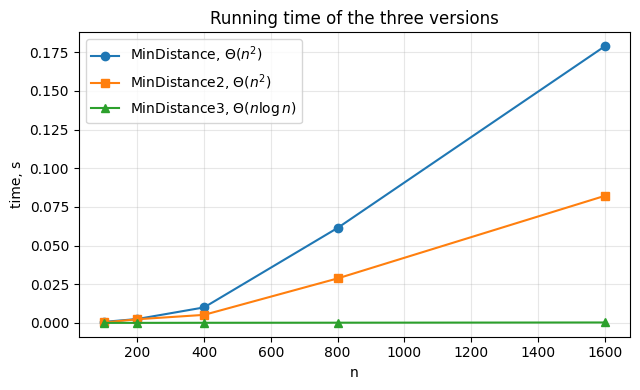

In [14]:
sizes = [100, 200, 400, 800, 1600]
t_orig, t_impr, t_sort = [], [], []
for n in sizes:
    A = random.sample(range(10**8), n)
    for f, store in ((min_distance, t_orig), (min_distance2, t_impr), (min_distance3, t_sort)):
        t0 = time.perf_counter(); f(A); store.append(time.perf_counter() - t0)

plt.figure(figsize=(6.5, 4))
plt.plot(sizes, t_orig, "o-", label="MinDistance, $\\Theta(n^2)$")
plt.plot(sizes, t_impr, "s-", label="MinDistance2, $\\Theta(n^2)$")
plt.plot(sizes, t_sort, "^-", label="MinDistance3, $\\Theta(n\\log n)$")
plt.xlabel("n"); plt.ylabel("time, s"); plt.title("Running time of the three versions")
plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

| Version | Main-loop iterations | Order of growth |
|---|---|---|
| MinDistance (original) | $n^2$ | $\Theta(n^2)$ |
| MinDistance2 | $n(n-1)/2$ | $\Theta(n^2)$ |
| MinDistance3 | $n-1$ (after sorting) | $\Theta(n\log n)$ |

The best version is **MinDistance3**: sort and compare neighbors in $\Theta(n\log n)$. If sorting is undesirable, MinDistance2 reduces the number of operations by a factor of 2-4.

---
# Summary of answers

In [15]:
g, rows_e = euclid_trace(31415, 14142)
d_cons = consecutive_check(31415, 14142)[1]
summary = [
    ("0.1", "MaxValue: n - 1 comparisons, Theta(n)."),
    ("0.2", "Average: n additions + 1 division, Theta(n)."),
    ("1.1.4", "FloorSqrt computes floor(sqrt n) in floor(sqrt n) iterations; binary-search version runs in O(log n)."),
    ("1.1.6", f"gcd(31415, 14142) = {g}; Euclid: {len(rows_e)} divisions, consecutive checking: {d_cons}; speed-up about {d_cons/len(rows_e):.0f} times."),
    ("1.1.7", "gcd(m, n) = gcd(n, m mod n): both pairs have the same set of common divisors."),
    ("1.1.8", "For m < n the first iteration swaps the numbers; this happens at most once."),
    ("1.1.9", f"For 1 <= m, n <= 10: minimum = {dmin} division, maximum = {dmax} (pair (5, 8))."),
    ("1.2.4", "Real roots of ax^2 + bx + c = 0, all cases handled (including a = 0)."),
    ("1.2.5", "Binary representation: repeated division by 2, remainders read in reverse order."),
    ("1.2.6", "ATM: PIN check, limits, greedy selection of bills, rollback on fault."),
    ("1.2.9", "MinDistance: n^2 -> n(n-1)/2 iterations; with presorting Theta(n log n)."),
]
display(pd.DataFrame(summary, columns=["No.", "Result"]).set_index("No."))

,Result
No.,
0.1,"MaxValue: n - 1 comparisons, Theta(n)."
0.2,"Average: n additions + 1 division, Theta(n)."
1.1.4,FloorSqrt computes floor(sqrt n) in floor(sqrt n) iterations; binary-search version runs in O(log n).
1.1.6,"gcd(31415, 14142) = 1; Euclid: 10 divisions, consecutive checking: 14149; speed-up about 1415 times."
1.1.7,"gcd(m, n) = gcd(n, m mod n): both pairs have the same set of common divisors."
1.1.8,For m < n the first iteration swaps the numbers; this happens at most once.
1.1.9,"For 1 <= m, n <= 10: minimum = 1 division, maximum = 5 (pair (5, 8))."
1.2.4,"Real roots of ax^2 + bx + c = 0, all cases handled (including a = 0)."
1.2.5,"Binary representation: repeated division by 2, remainders read in reverse order."


---
# Appendix. LaTeX sources (`algorithm2e` and `algpseudocode`)
To get the same pseudocode in a stand-alone `.tex` report, use one of the two packages (do not load both at once).

**Variant 1: `algorithm2e`** (the most popular package for pseudocode)

```latex
\documentclass[12pt]{article}
\usepackage[utf8]{inputenc}
\usepackage[ruled,vlined,linesnumbered]{algorithm2e}
\usepackage{amsmath,amssymb}
\begin{document}

\begin{algorithm}[H]
  \caption{Euclid$(m,n)$}
  \KwIn{non-negative integers $m,n$, not both zero}
  \KwOut{$\gcd(m,n)$}
  \While{$n \neq 0$}{
    $r \gets m \bmod n$\;
    $m \gets n$\;
    $n \gets r$\;
  }
  \Return{$m$}\;
\end{algorithm}

\begin{algorithm}[H]
  \caption{MinDistance2$(A[0..n-1])$}
  \KwIn{array $A[0..n-1]$, $n\ge 2$}
  \KwOut{minimum distance between two of its elements}
  $d_{\min}\gets\infty$\;
  \For{$i\gets 0$ \KwTo $n-2$}{
    \For{$j\gets i+1$ \KwTo $n-1$}{
      $temp\gets |A[i]-A[j]|$\;
      \lIf{$temp<d_{\min}$}{$d_{\min}\gets temp$}
    }
  }
  \Return{$d_{\min}$}\;
\end{algorithm}

\end{document}
```

**Variant 2: `algpseudocode`** (from the `algorithmicx` bundle)

```latex
\usepackage{algorithm}
\usepackage{algpseudocode}

\begin{algorithm}
  \caption{Euclid$(m,n)$}
  \begin{algorithmic}[1]
    \Require non-negative integers $m,n$, not both zero
    \Ensure $\gcd(m,n)$
    \While{$n \neq 0$}
      \State $r \gets m \bmod n$
      \State $m \gets n$
      \State $n \gets r$
    \EndWhile
    \State \Return $m$
  \end{algorithmic}
\end{algorithm}
```